# Reproducing the MuVIcell tutorial with MINA

[MuVIcell](https://github.com/HartmannLab/MuVIcell) demonstrated *multicellular
factor analysis*: starting from pseudo-bulked, cell-type–stratified features, it
used **MuVI** to learn latent factors that capture coordinated programs across
cell types, and then related those factors to sample-level covariates.

**MINA** generalises this workflow. The factor-decomposition step is more
flexible — MINA builds on [MOFA-FLEX](https://github.com/bioFAM/mofaflex), which
supports several priors and likelihoods — while the downstream statistics and
visualisations mirror (and extend) MuVIcell. This notebook reproduces the
MuVIcell tutorial end to end with MINA.

!!! note "About the data"
    MuVIcell's *synthetic data generator* is **not** part of MINA. We ran
    MuVIcell's own `synthetic.generate_synthetic_data` + `add_latent_structure`
    **once** and exported the resulting object to
    `data/muvicell_synthetic.h5mu` (200 samples × 3 cell-type views, a known
    3-factor latent structure, and an ordinal `exposure` covariate correlated
    with factor 1). The example loads that object directly.

!!! tip "Requirements"
    `pip install "mina[spatial]"` (for the plotting helpers) and a working
    `mofaflex` install (Python ≥ 3.11).

In [1]:
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt

import mofaflex as mf
import mina

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## 1. Load the pseudo-bulked multi-view object

MINA operates on a *dictionary of per-view `AnnData` objects* together with a
sample-level metadata table (one row per sample).

In [2]:
mdata = md.read("data/muvicell_synthetic.h5mu")

anndata_dict = {view: mdata[view].copy() for view in mdata.mod}

metadata = mdata.obs.copy()
metadata["sample_id"] = metadata.index.astype(str)
mdata

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 200 × 30
  obs:	'sim_factor_1', 'sim_factor_2', 'sim_factor_3', 'batch', 'exposure'
  uns:	'true_factor_loadings', 'true_factor_variance'
  obsm:	'true_factors'
  3 modalities
    Cell Type 1:	200 x 5
      obs:	'sample_id', 'batch', 'total_counts'
      var:	'gene_name', 'highly_variable'
      varm:	'true_factor_loadings'
    Cell Type 2:	200 x 10
      obs:	'sample_id', 'batch', 'total_counts'
      var:	'gene_name', 'highly_variable'
      varm:	'true_factor_loadings'
    Cell Type 3:	200 x 15
      obs:	'sample_id', 'batch', 'total_counts'
      var:	'gene_name', 'highly_variable'
      varm:	'true_factor_loadings'

## 2. Preprocessing

MuVIcell centred and scaled each view independently. MINA reproduces this exact
behaviour with `norm_log(method="zscore")`. We then prefix each feature with its
view name so the model and the downstream helpers can reconstruct view-specific
loadings.

In [3]:
mina.up.norm_log(anndata_dict, method="zscore")
mina.up.utils.append_view_to_var(anndata_dict)

Per-view z-score normalization complete for all AnnData objects.


## 3. Factor decomposition (MOFA-FLEX)

Where MuVIcell called MuVI, MINA uses the flexible MOFA-FLEX engine. We request
3 factors to match the injected latent structure and use a spike-and-slab weight
prior for sparse, interpretable loadings.

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymor

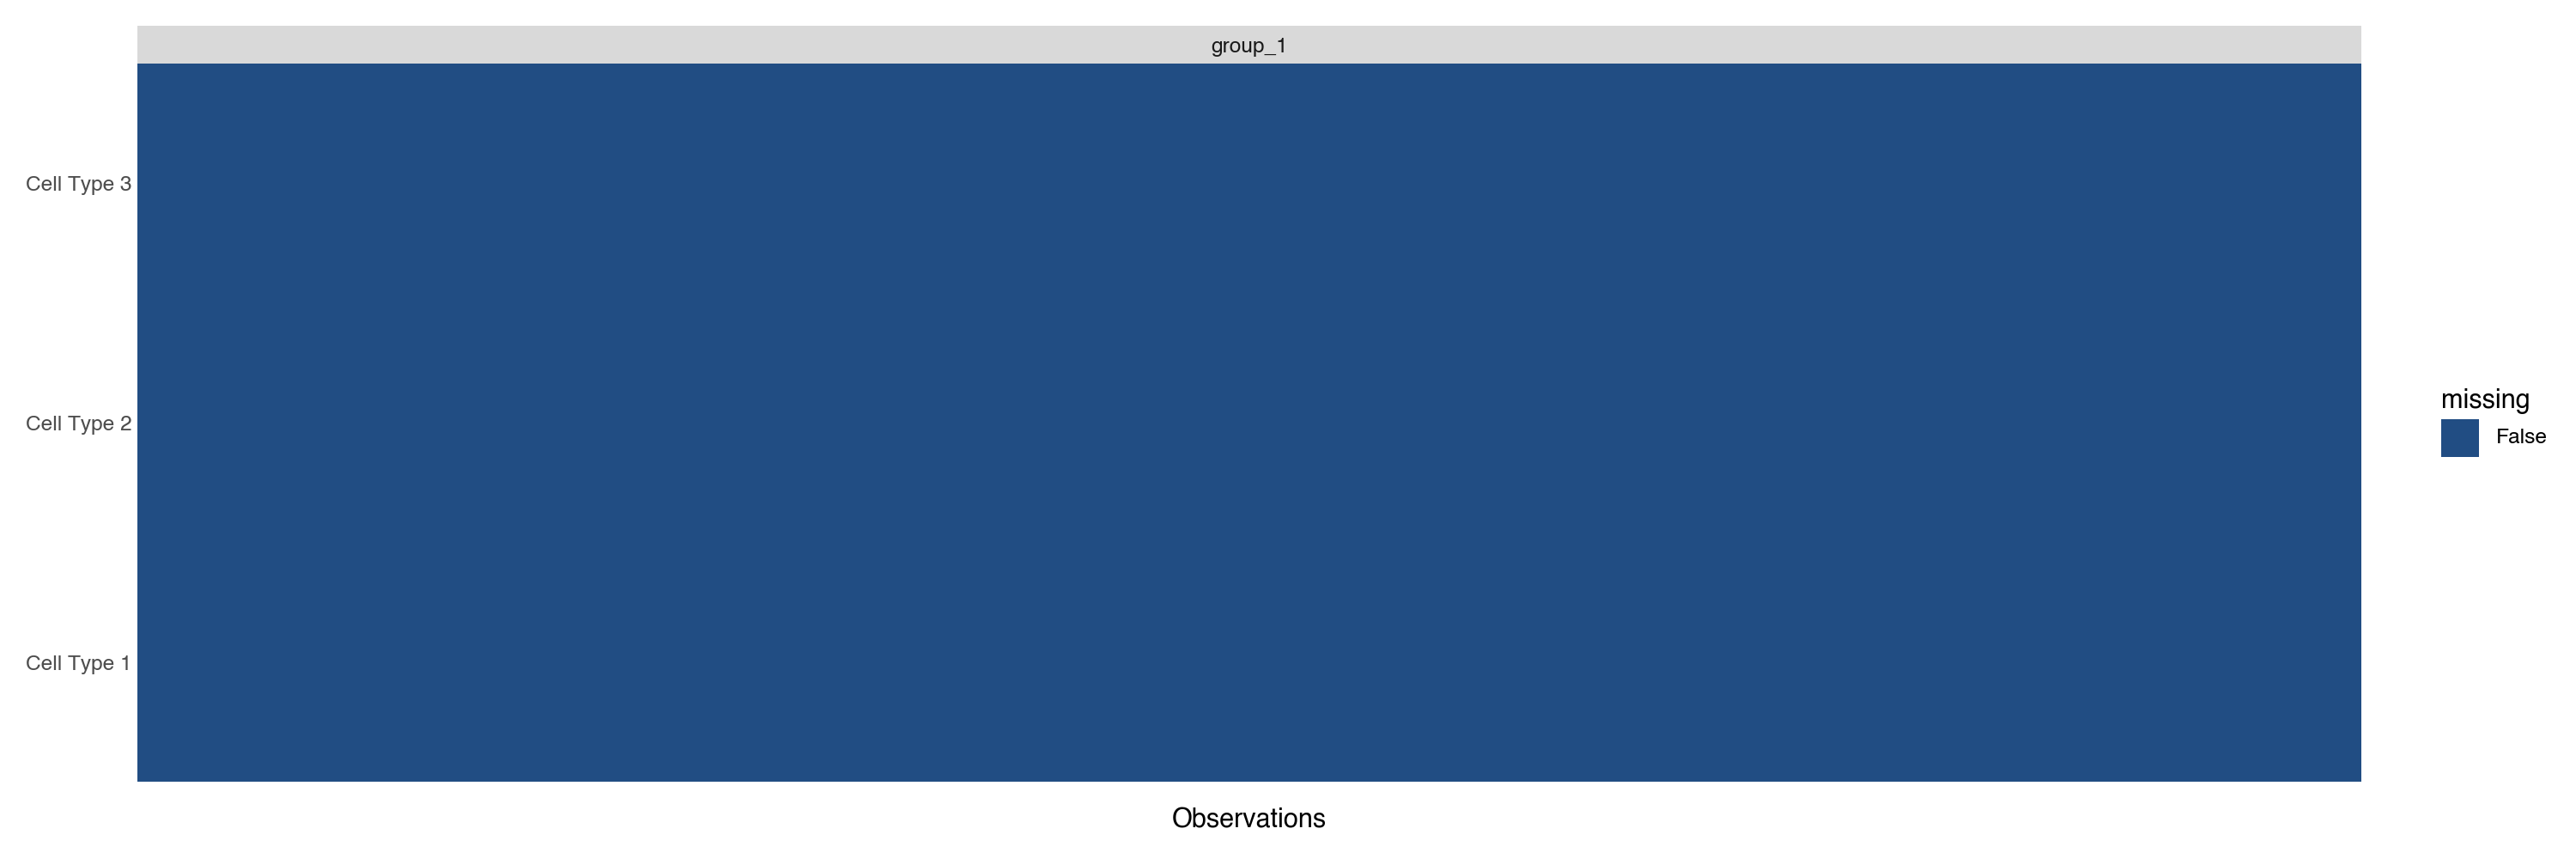

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymor

In [4]:
mdata_model = md.MuData(anndata_dict)

model = mf.terms.MofaFlex(
    n_factors=3,
    weight_prior="SpikeSlab",
    init_factors="pca",
)
model.fit(
    mdata_model,
    seed=42,
    lr=0.01,
    early_stopper_patience=1000,
    subset_var=None,
    save_path=False,
    likelihoods="Normal",
)

## 4. Assemble a model `AnnData`

`model_to_anndata` collects factor scores (`.X`), explained variance per factor
and view (`.var`), gene loadings (`.varm`) and the aligned pseudo-bulk matrices
(`.obsm`) into a single annotated object that all downstream functions consume.

In [5]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)
amodel

AnnData object with n_obs × n_vars = 200 × 3
    obs: 'Cell Type 1:sample_id', 'Cell Type 1:batch', 'Cell Type 1:total_counts', 'Cell Type 2:sample_id', 'Cell Type 2:batch', 'Cell Type 2:total_counts', 'Cell Type 3:sample_id', 'Cell Type 3:batch', 'Cell Type 3:total_counts', 'sim_factor_1', 'sim_factor_2', 'sim_factor_3', 'batch', 'exposure', 'sample_id', 'Cell Type 1_n_cells', 'Cell Type 2_n_cells', 'Cell Type 3_n_cells'
    var: 'Cell Type 1:group_1', 'Cell Type 2:group_1', 'Cell Type 3:group_1'
    uns: 'gene_loadings_columns', 'Cell Type 1_columns', 'Cell Type 2_columns', 'Cell Type 3_columns'
    obsm: 'Cell Type 1', 'Cell Type 2', 'Cell Type 3'
    varm: 'gene_loadings'

## 5. Variance explained and reconstruction quality

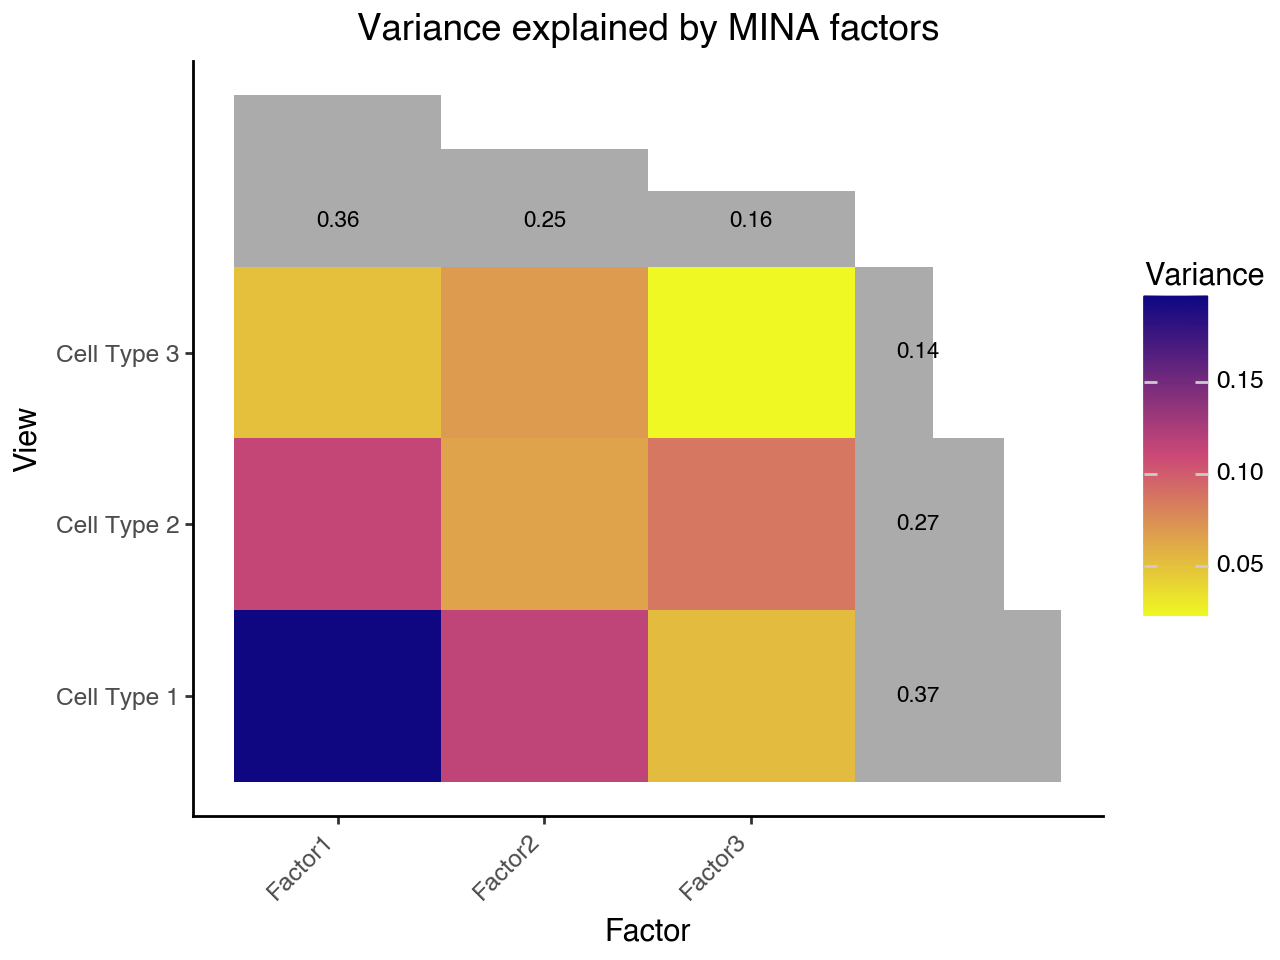

In [6]:
variance_df = mina.down.variance_by_view_info(amodel)
mina.pl.plot_variance_by_view(variance_df)

Macro R2: 0.272


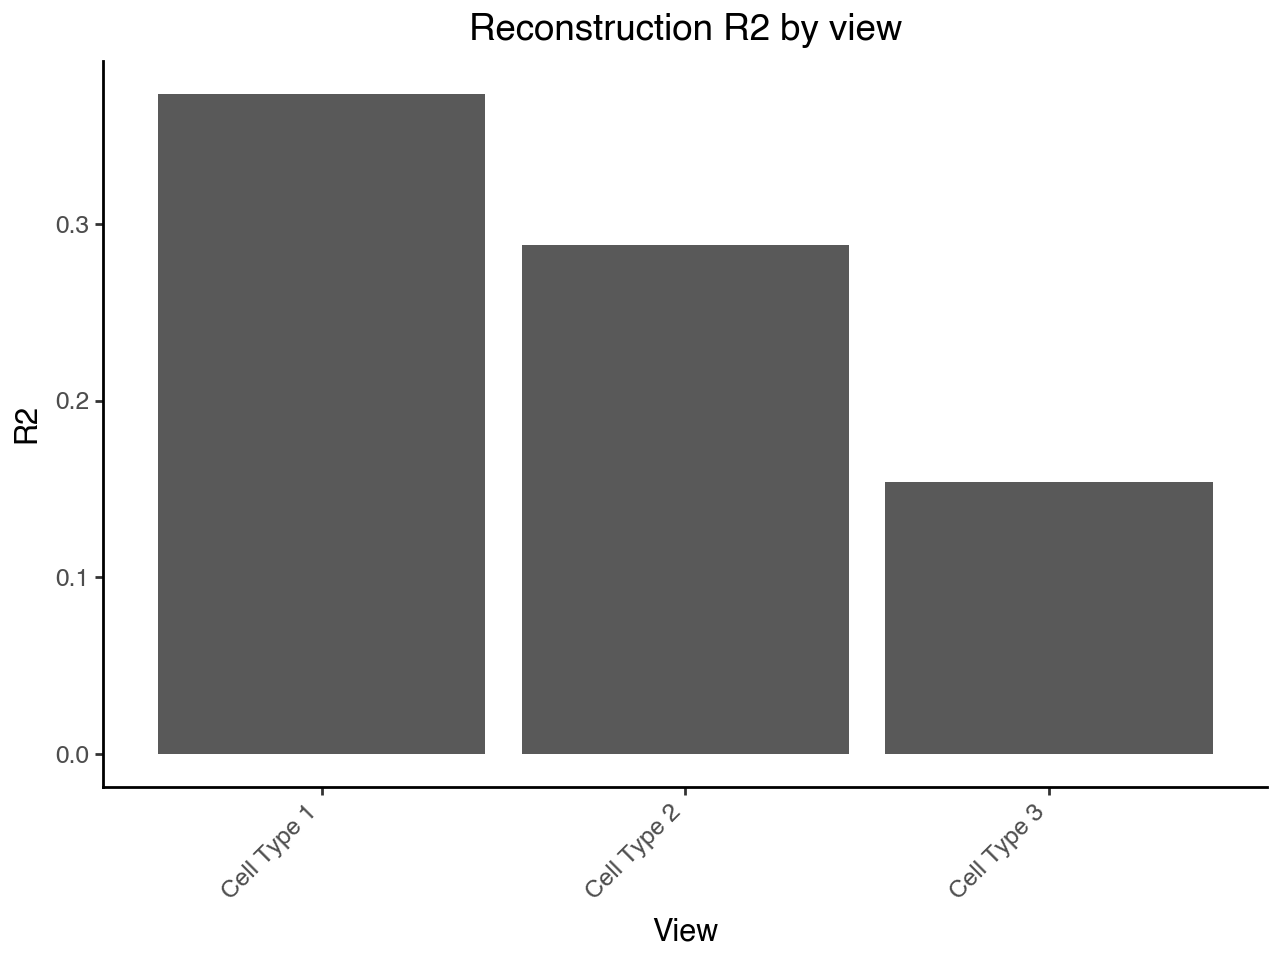

In [7]:
reconstruction = mina.down.reconstruction_info(amodel)
print("Macro R2:", round(reconstruction["macro"]["R2"], 3))
mina.pl.plot_reconstruction(reconstruction["by_view"])

## 6. Associating factors with covariates

The tutorial injected an ordinal `exposure` variable correlated with factor 1.
MINA offers a Kruskal–Wallis test (categorical groups) and a Kendall tau test
(ordinal variables). By default both apply a Bonferroni correction across factors, reported in a clearly named column (`pvalue_bonferroni`) alongside the raw `pvalue`; pass `correction="fdr_bh"` for Benjamini-Hochberg FDR or `correction=None` for uncorrected p-values.

In [8]:
scores = mina.down.factor_scores_info(amodel, obs_keys=["exposure", "batch"])

kruskal_df = mina.down.kruskal_info(scores, group_col="exposure")
kruskal_df

,factor,pvalue
0,Factor2,0.000211
1,Factor1,0.032093
2,Factor3,1.000000


In [9]:
scores["exposure_ordinal"] = scores["exposure"].cat.codes
mina.down.kendall_info(scores, ordinal_col="exposure_ordinal")

,factor,tau,pvalue
0,Factor2,-0.238782,0.000045
1,Factor1,0.166183,0.007734
2,Factor3,-0.073670,0.544503


/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


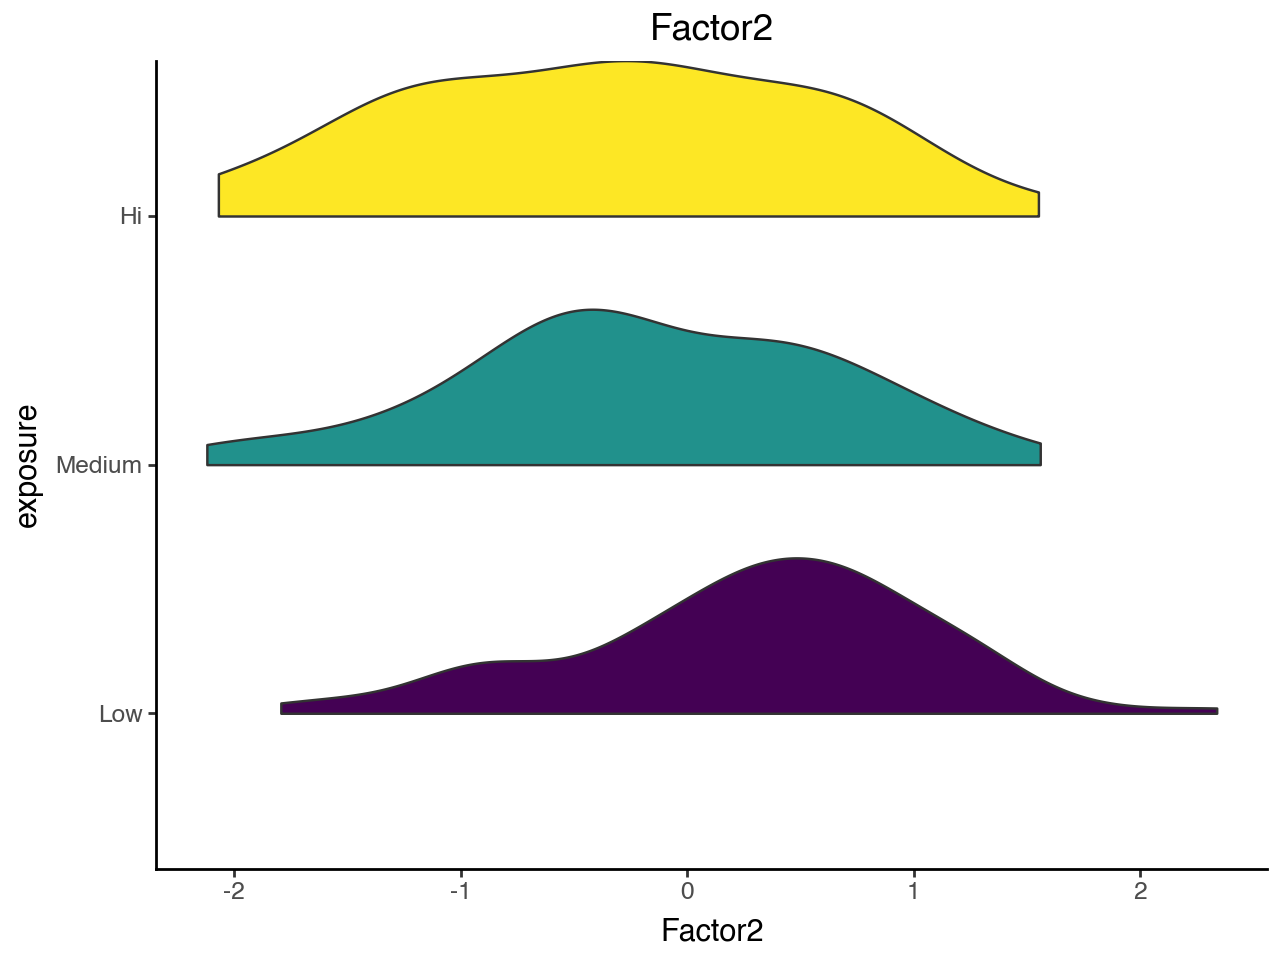

In [10]:
top_factor = kruskal_df.iloc[0]["factor"]
mina.pl.plot_factor_violin(scores, factor=top_factor, group_col="exposure")

A compact way to screen many covariates at once is the adjusted p-value
matrix (factors × covariates).

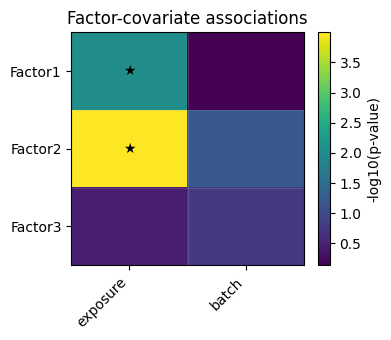

In [11]:
pval_matrix = mina.down.get_pval_matrix(amodel, ["exposure", "batch"])
mina.pl.plot_pval_tiles(pval_matrix, title="Factor-covariate associations", star_threshold=0.05)
plt.show()

## 7. Loadings and top features

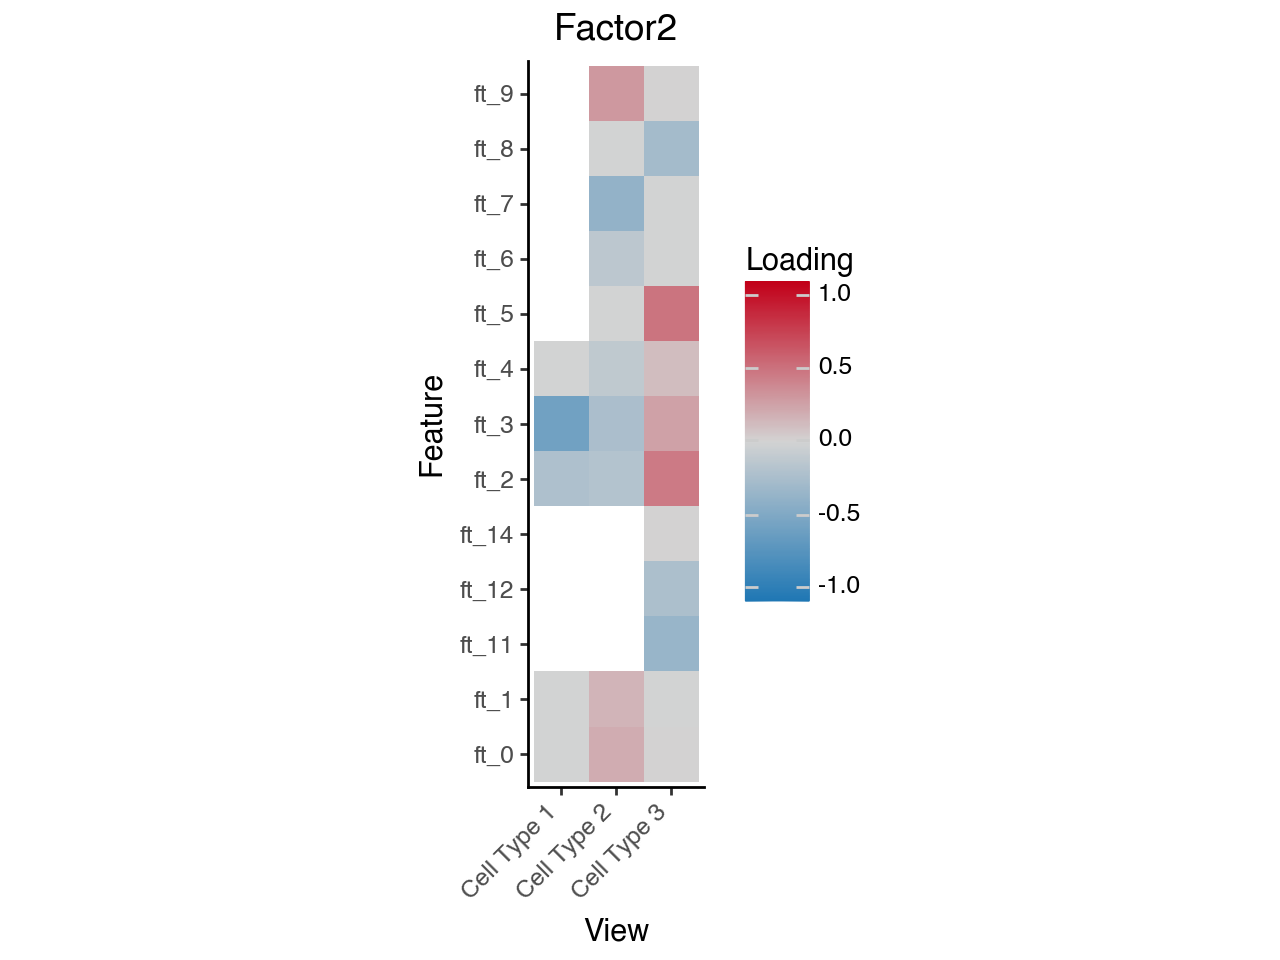

In [12]:
loadings = mina.down.variable_loadings_info(amodel)
mina.pl.plot_top_loadings_heatmap(loadings, factor=top_factor, top_n=20)

In [13]:
top_features = mina.down.top_features_by_view_info(
    loadings, factors=[top_factor], top_per_view=3
)
top_features

,variable,view,weight,factor
0,ft_3,Cell Type 1,-0.599186,Factor2
1,ft_5,Cell Type 3,0.495781,Factor2
2,ft_2,Cell Type 3,0.462282,Factor2
3,ft_7,Cell Type 2,-0.389706,Factor2
4,ft_11,Cell Type 3,-0.357982,Factor2
5,ft_9,Cell Type 2,0.309754,Factor2
6,ft_3,Cell Type 2,-0.244160,Factor2
7,ft_2,Cell Type 1,-0.229331,Factor2
8,ft_1,Cell Type 1,-0.000022,Factor2


## 8. Sample structure in factor space

Confidence ellipses summarise how groups separate along a pair of factors.

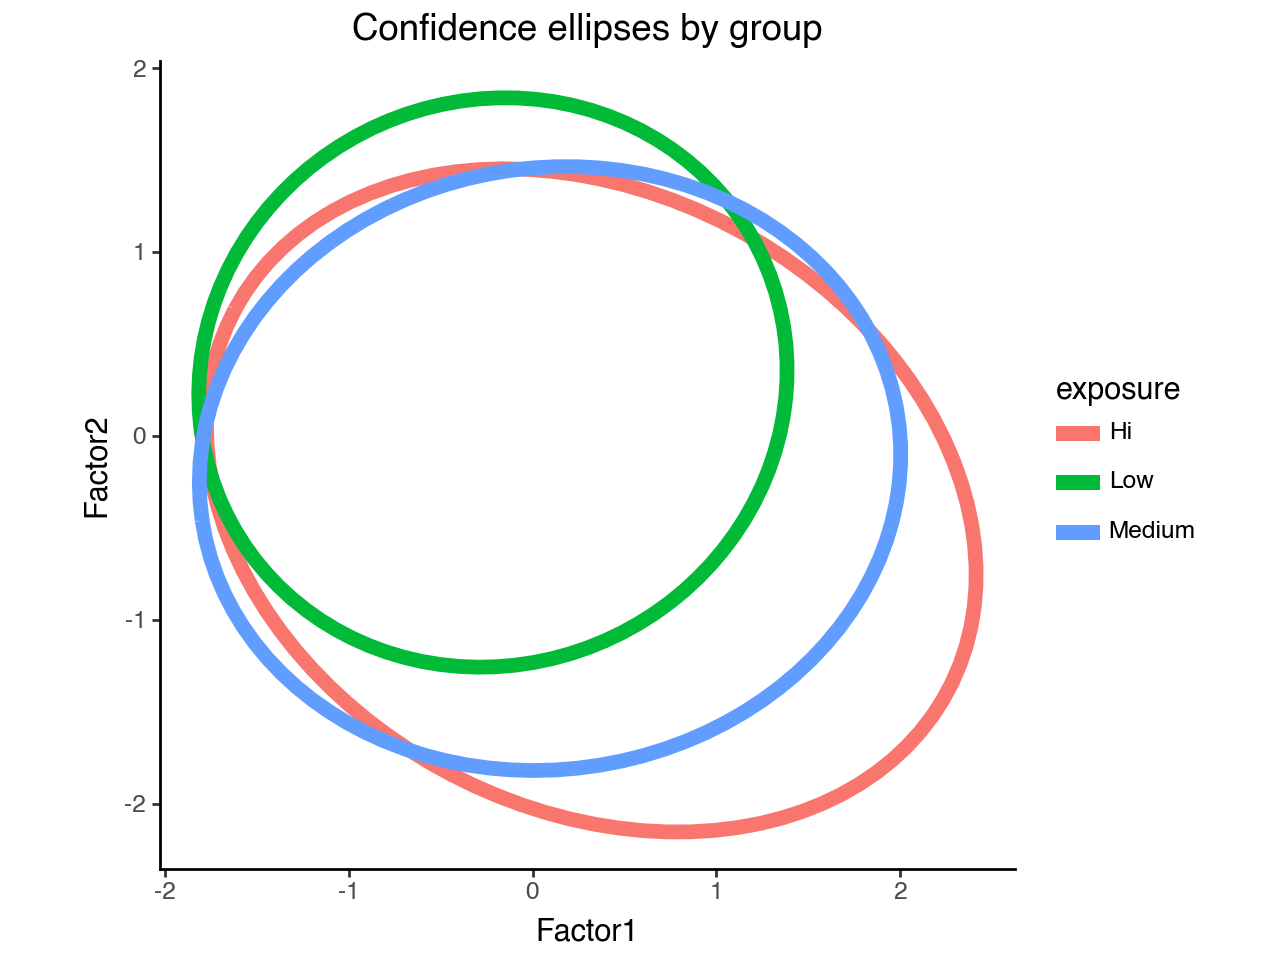

In [14]:
ellipse_df = mina.down.confidence_ellipses_info(
    scores, x_factor="Factor1", y_factor="Factor2", group_col="exposure"
)
mina.pl.plot_confidence_ellipses(
    scores, ellipse_df, x_factor="Factor1", y_factor="Factor2", group_col="exposure"
)

## 9. Exporting selected features

Mirroring MuVIcell's final step, `build_selected_anndata` materialises a small
`AnnData` containing only the selected (feature, view) pairs — handy for
downstream visualisation or sharing.

In [15]:
selected = mina.down.build_selected_anndata(amodel, top_features)
selected

AnnData object with n_obs × n_vars = 200 × 9
    obs: 'Cell Type 1:sample_id', 'Cell Type 1:batch', 'Cell Type 1:total_counts', 'Cell Type 2:sample_id', 'Cell Type 2:batch', 'Cell Type 2:total_counts', 'Cell Type 3:sample_id', 'Cell Type 3:batch', 'Cell Type 3:total_counts', 'sim_factor_1', 'sim_factor_2', 'sim_factor_3', 'batch', 'exposure', 'sample_id', 'Cell Type 1_n_cells', 'Cell Type 2_n_cells', 'Cell Type 3_n_cells'
    var: 'variable', 'view', 'variable_view'

## Summary

Using MINA we reproduced the MuVIcell tutorial: per-view z-scoring, a 3-factor
decomposition (via MOFA-FLEX), variance-explained and reconstruction summaries,
factor–covariate association tests, loading inspection and confidence ellipses.
The only conceptual change is the decomposition engine — everything downstream
follows the same logic, now available through a single `mina.down` / `mina.pl`
API.

See *Best practices for spatial proteomics* for guidance on applying this
workflow to real imaging data, and the *MIBI colorectal cancer* case study for a
full real-data example.